## GIS thickness segmentation and measurement demo

In [1]:
%matplotlib inline
# Imports
import sys
sys.path.append("..")

import tifffile
import matplotlib.pyplot as plt
import numpy as np
import yaml

In [4]:
with open("protocol-on-grid-adaptive-polish-dl.yaml", "r") as f:
    config = yaml.safe_load(f)

In [6]:
adaptive_polish_settings =config["adaptive_polish"]

In [7]:
from adaptive_polish import franklin_adaptive_milling_dl_fibsem2
ap2 = franklin_adaptive_milling_dl_fibsem2.AdaptiveMilling(adaptive_polish_settings)

c:\Users\Luis-work\miniconda3\envs\franklin_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Default configuration: microscope-configuration-demo2
Default configuration path: C:/Users/Luis-work/Desktop/Others/openfibsem/git-rfi-fibsem/fibsem/config/microscope-configuration-demo2.yaml


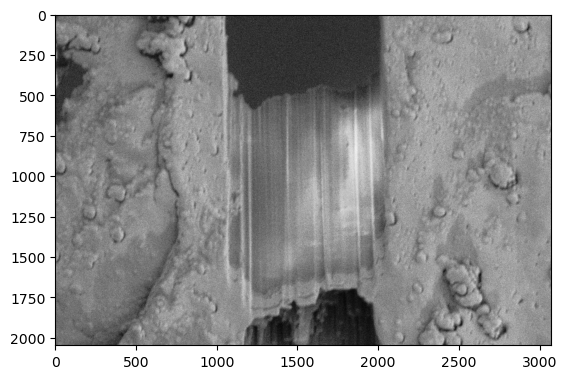

In [8]:
img_fname = r"C:\Users\Luis-work\OneDrive - The Rosalind Franklin Institute\Projects\2023_AutomatedAdaptiveMillingGIS\Franklin_2024-05-21_lam_007\SEM\Franklin_2024-05-21_lam_007_img_000.tif"

img = tifffile.imread(img_fname)
plt.imshow(img, cmap="Greys_r")


In [10]:
print(img.shape)
print(img.dtype)

(2048, 3072)
uint8


# GIS thickness by DL

In [12]:
import adaptive_polish.gis_measurement as gm

In [13]:
# Segmentation
prediction = gm.segment(img)

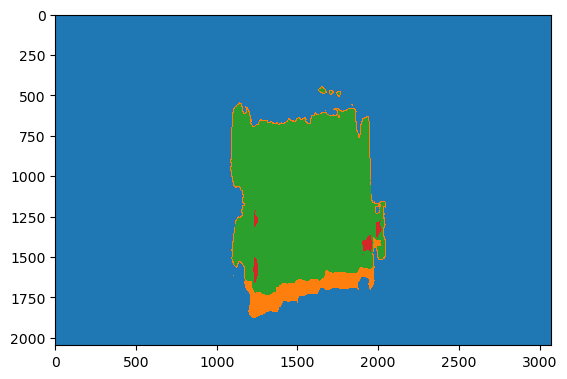

In [14]:
plt.imshow(prediction, cmap="tab10", vmin=0, vmax=10)

In [18]:
prediction = gm.segment(img)
pixel_size_m = float(adaptive_polish_settings["fallback_pixel_size_m"])
mask_gis_clean = gm.clean_prediction(
    prediction,
    pixel_size_m,
    float(adaptive_polish_settings["lam_height_min_m"]),
    float(adaptive_polish_settings["reject_GIS_distance_m"])
)


(-0.5, 3071.5, 2047.5, -0.5)

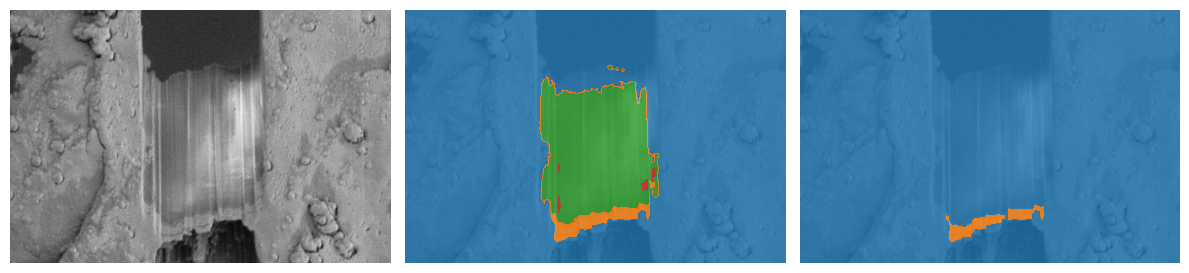

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 8), tight_layout=True)
axs[0].imshow(img, cmap='Greys_r')
axs[0].axis("off")

axs[1].imshow(img, cmap='Greys_r')
axs[1].imshow(prediction, cmap='tab10', alpha=0.8, vmin=0, vmax=10)
axs[1].axis("off")

axs[2].imshow(img, cmap='Greys_r')
axs[2].imshow(mask_gis_clean, cmap='tab10', alpha=0.8, vmin=0, vmax=10)
axs[2].axis("off")

(-0.5, 3071.5, 2047.5, -0.5)

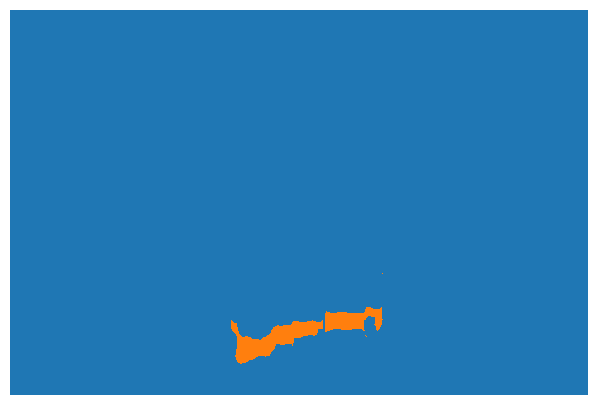

In [20]:
fig,ax = plt.subplots(1,1,figsize=(9,5))
ax.imshow(mask_gis_clean, cmap="tab10", vmin=0, vmax=10)
ax.axis("off")

In [21]:
# Get overlap between prediction and cleaned version
overlap = prediction + mask_gis_clean*4

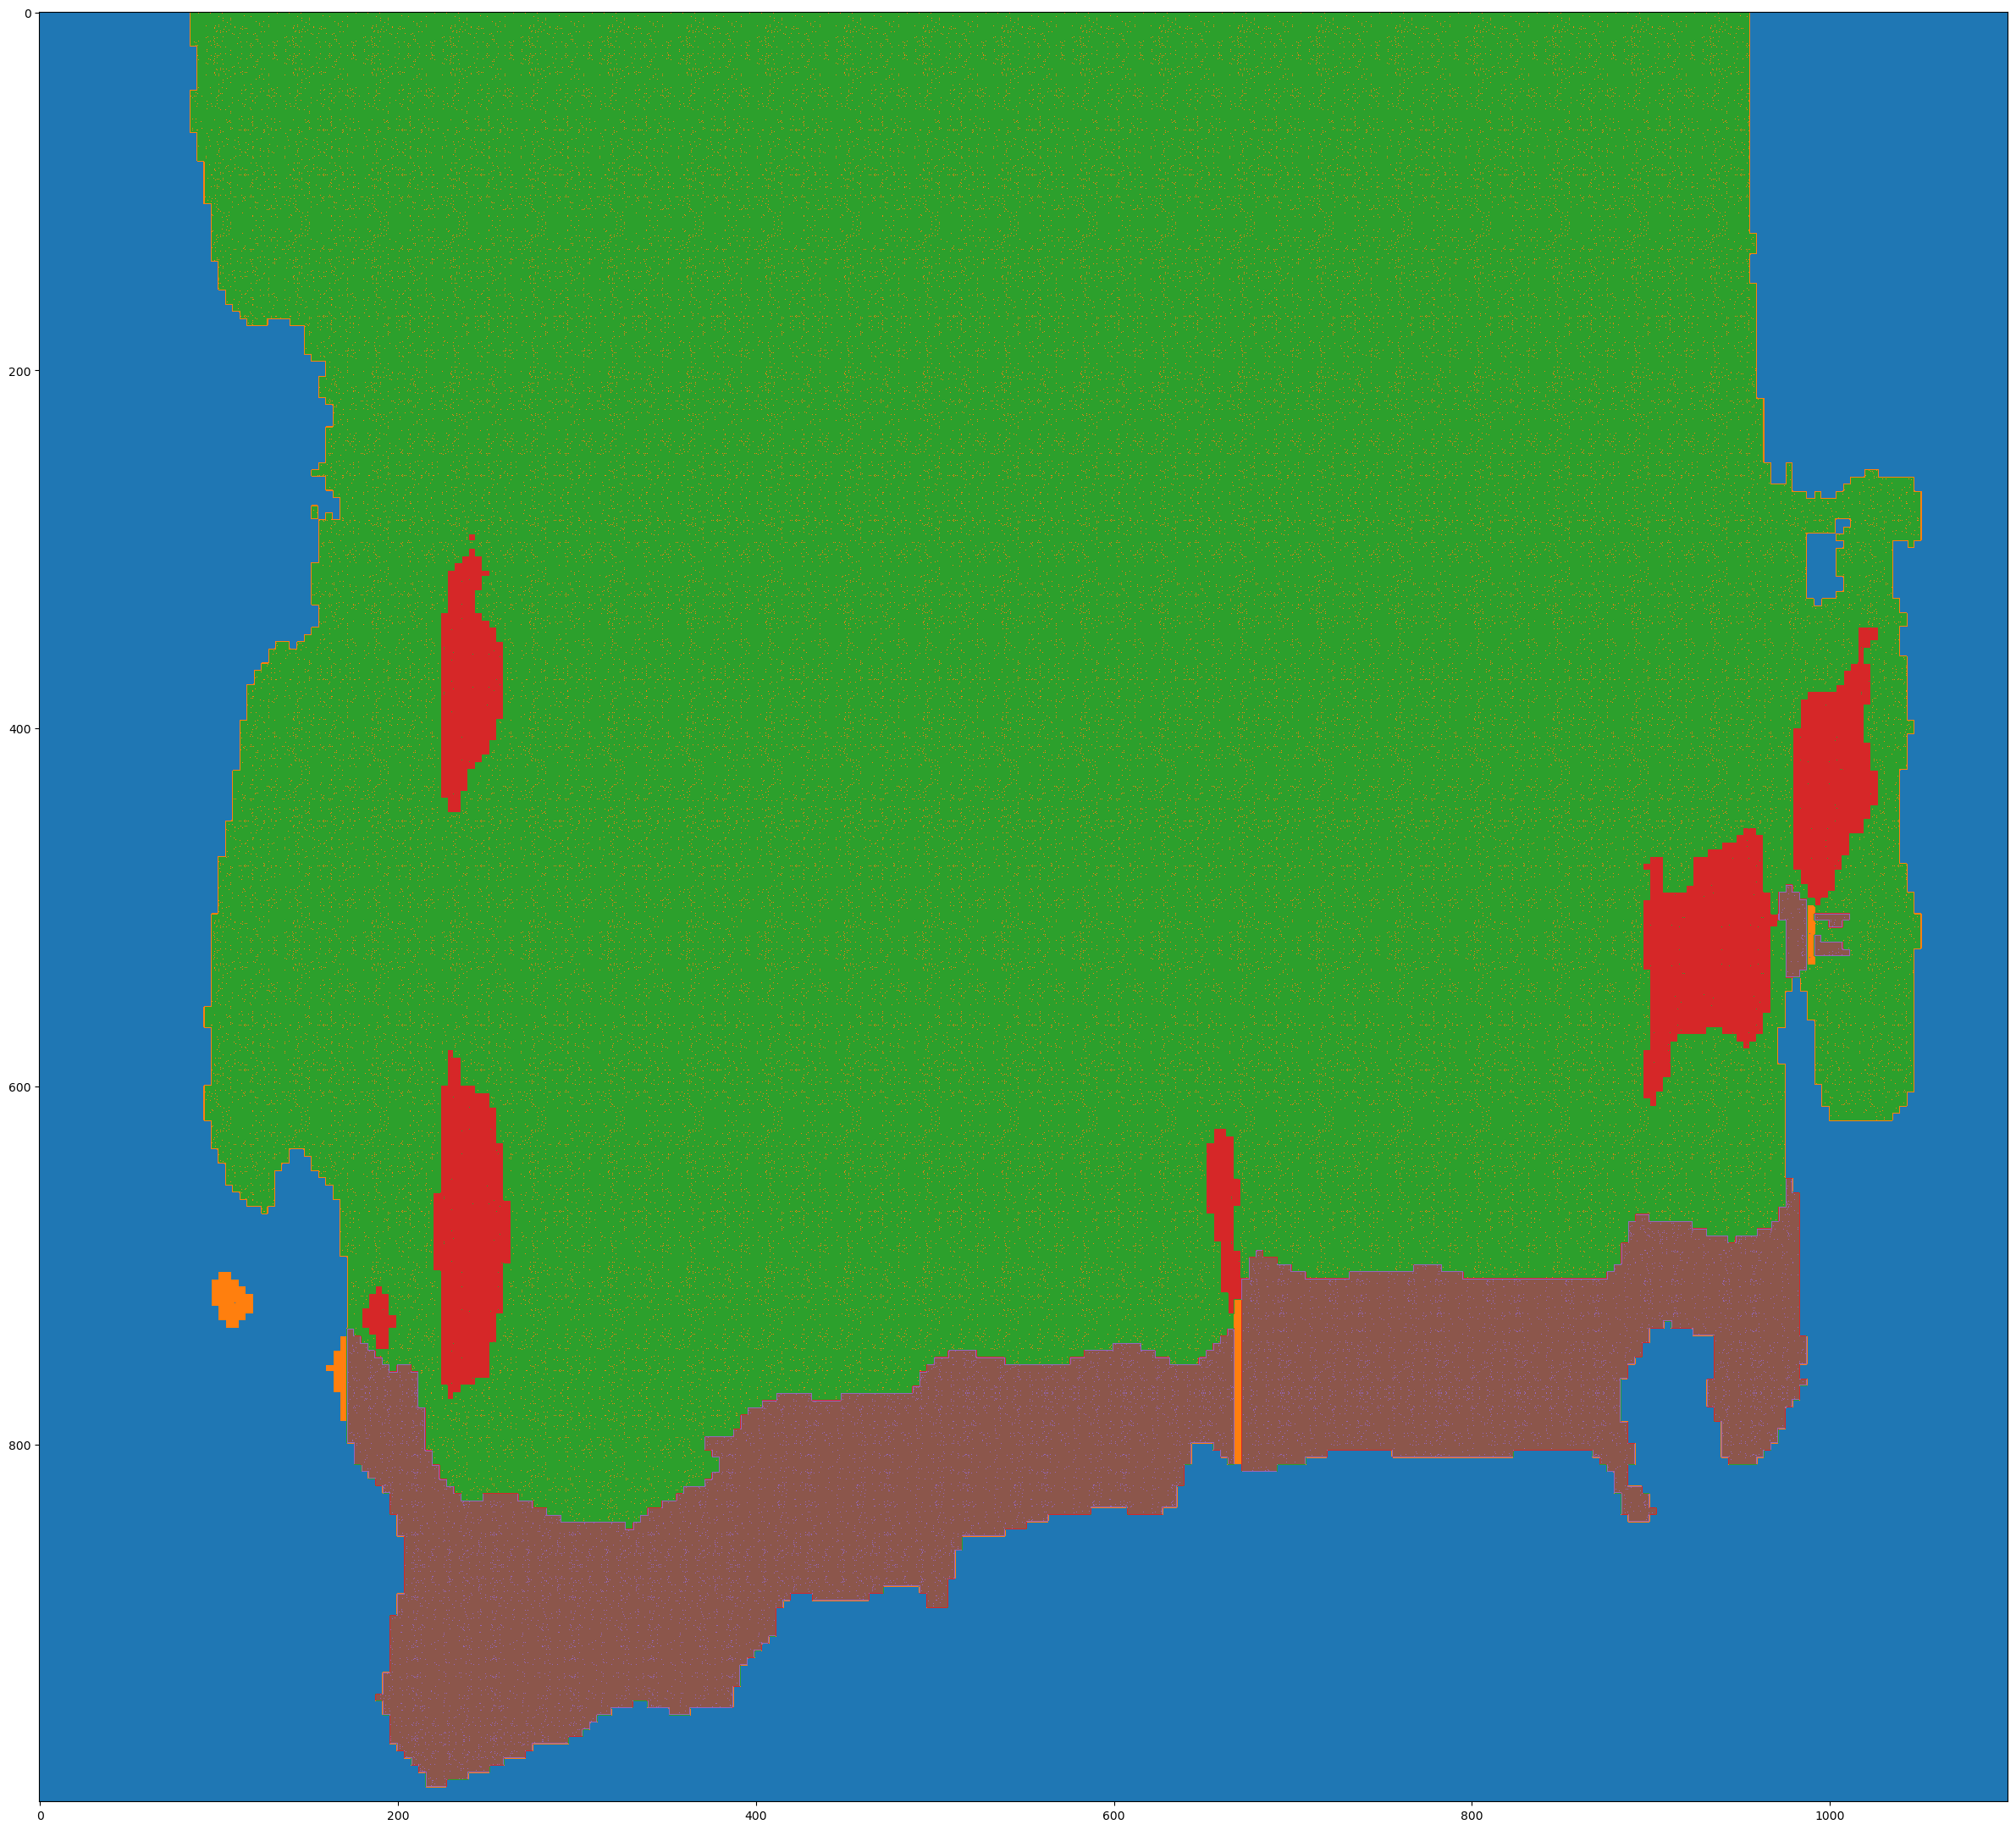

In [22]:
fig,ax = plt.subplots(1,1,figsize=(30,30))
ax.imshow(overlap[900:1900,1000:2100], cmap="tab10", vmin=0, vmax=10)

In [23]:
pixel_size_m = adaptive_polish_settings["fallback_pixel_size_m"]

In [27]:
GIS_m, xlims = gm.measure_GIS(mask_gis_clean, float(adaptive_polish_settings["window_size_m"]), pixel_size_m)

C:\Users\Luis-work\Desktop\Others\openfibsem\git-rfi-adaptive_polish\src\adaptive_polish\gis_measurement.py:168: RuntimeWarning: Mean of empty slice
  GIS_windowed = np.nanmean(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)


In [28]:
crack_area_m2 = gm.get_crack_area_m2(prediction, pixel_size_m, *xlims)

AttributeError: 'NoneType' object has no attribute 'write'

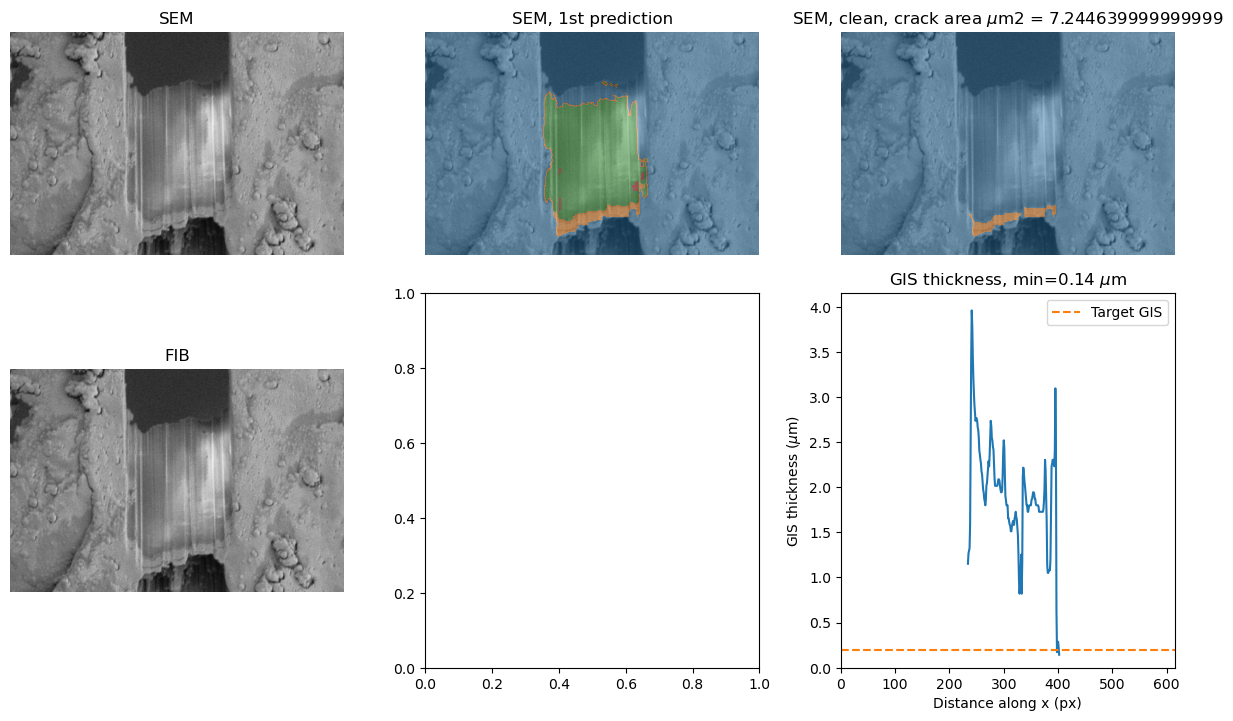

In [31]:
gm.milling_cycle_plot(
    sem_image=img,
    first_prediction=prediction,
    clean_prediction=mask_gis_clean,
    fib_image=img,
    gis_thickness_m=GIS_m,
    gis_stop_m= float(adaptive_polish_settings["gis_stop_m"]),
    crack_area_m2=crack_area_m2,
    img_name=None,
    save_path=None,
)